In [1]:
import pandas as pd

df = pd.read_csv("lightcast_job_postings.csv")

C:\Users\DELL\AppData\Local\Temp\ipykernel_20788\2462282455.py:3: DtypeWarning: Columns (19,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lightcast_job_postings.csv")


In [2]:
df_ai = df[df['SKILLS_NAME'].str.contains('Artificial Intelligence', case=False, na=False)].copy()
df_ai['AI_Category'] = 1

selected_skills = [
    'Python', 'SQL', 'Machine Learning', 'Cloud Computing', 'Docker',
    'AWS', 'communication', 'leadership', 'problem solving',
    'project management', 'business process'
]
skill_pattern = '|'.join(selected_skills)
mask_selected_skills = df['SKILLS_NAME'].str.contains(skill_pattern, case=False, na=False)
df_selected_subset = df[mask_selected_skills].copy()
print(df_selected_subset.shape[0])

62233


In [ ]:
df['LOT_CAREER_AREA_NAME'].unique()


In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse=False)
encoded_lot = encoder.fit_transform(df_selected_subset[['LOT_CAREER_AREA_NAME']])
encoded_lot_df = pd.DataFrame(encoded_lot, columns=encoder.get_feature_names_out(['LOT_CAREER_AREA_NAME']))
encoded_lot_df.index = df_selected_subset.index
df_cluster_input = pd.concat([df_selected_subset, encoded_lot_df], axis=1)

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\

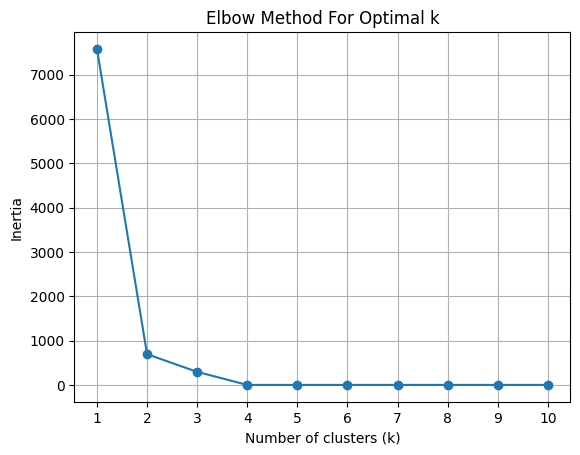

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_cluster = encoded_lot_df
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [16]:
X_cluster = encoded_lot_df
kmeans = KMeans(n_clusters=2, random_state=517)
kmeans.fit(X_cluster)
df_cluster_input['Cluster'] = kmeans.labels_

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [17]:
pd.crosstab(df_cluster_input['Cluster'], df_cluster_input['LOT_CAREER_AREA_NAME'])

LOT_CAREER_AREA_NAME,Business Management and Operations,Healthcare,Information Technology and Computer Science,Marketing and Public Relations
Cluster,,,,
0,0,225,58203,148
1,3657,0,0,0


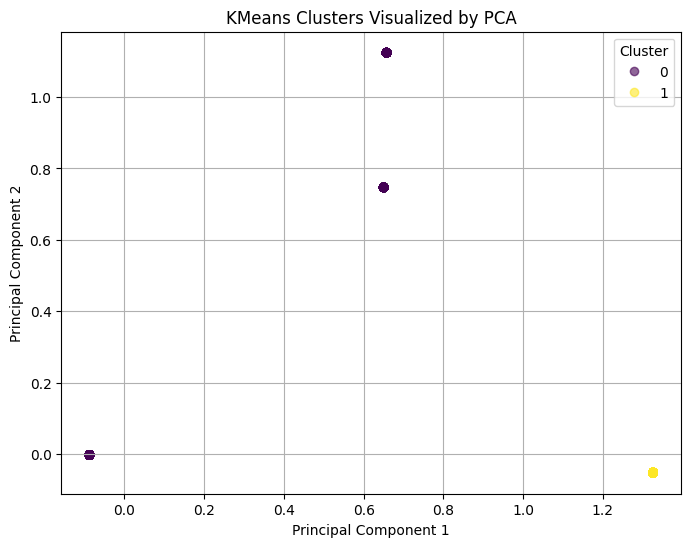

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df_cluster_input['Cluster'], cmap='viridis', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title('KMeans Clusters Visualized by PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

We conducted a KMeans clustering analysis using the LOT_CAREER_AREA_NAME attribute and use the Elbow Method to identify 2 as the optimal number of clusters. After applying KMeans clustering, we observed that Cluster 0 predominantly included roles in Information Technology and Computer Science, along with minor groups in Healthcare and Marketing, while Cluster 1 consisted entirely of Business Management and Operations roles. The clustering results reveal a separation between AI roles and business-oriented roles. For job seekers, this indicates that the current labor market offers distinct career pathways: one highly driven by emerging technologies such as Artificial Intelligence, Data Science, and Cloud Computing, and the other anchored in traditional business operations such as management, finance, and marketing.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

skill_keywords = [
    'Python', 'SQL', 'Machine Learning', 'Cloud Computing', 'Docker',
    'AWS', 'communication', 'leadership', 'problem solving',
    'project management', 'business process'
]
for skill in skill_keywords:
    df_selected_subset[skill+'_Skill'] = df_selected_subset['SKILLS_NAME'].str.contains(skill, case=False, na=False).astype(int)

if 'AI_Category' not in df_selected_subset.columns:
    df_selected_subset['AI_Category'] = df_selected_subset['SKILLS_NAME'].apply(
        lambda x: 1 if 'Artificial Intelligence' in str(x) or 'Machine Learning' in str(x) else 0
    )

df_regression = df_selected_subset.dropna(subset=['SALARY']).copy()

feature_cols = ['AI_Category'] + [skill+'_Skill' for skill in skill_keywords]
X = df_regression[feature_cols]
y = df_regression['SALARY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=517)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.2f}")

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

RMSE: 40782.77
R^2: 0.14
                     Feature   Coefficient
5               Docker_Skill  26684.071243
4      Cloud Computing_Skill  23161.589503
8           leadership_Skill  21152.581361
0                AI_Category  17700.524420
11    business process_Skill  11989.929809
6                  AWS_Skill  10651.316616
1               Python_Skill   5991.746939
10  project management_Skill   4074.292001
7        communication_Skill  -1110.729988
3     Machine Learning_Skill  -6146.435829
9      problem solving_Skill  -7785.989968
2                  SQL_Skill -12875.279938


The multiple regression analysis resulted in an RMSE of approximately $40,783 and an R² of 0.14, suggesting that while the model explains some variation in salary, many other unobserved factors likely contribute to salary outcomes. The primary predictor of interest, AI_Category, showed a positive and significant coefficient, indicating that AI-related careers generally offer a high salary. Skills associated with emerging technologies—such as Docker, Cloud Computing, and Python—also had strong positive relationships with salary. This suggests that technical skills highly relevant to AI development and deployment are valued in the labor market, further reinforcing the salary premium associated with AI careers. In contrast, traditional skills such as SQL and general problem-solving were associated with lower salary levels within the sample, which may reflect their broader prevalence across a wide range of lower-paying roles, including Non-AI occupations.

Recommendations: Based on the findings, job seekers are strongly encouraged to prioritize AI-related career tracks and emerging technology fields such as Machine Learning, Cloud Computing, and Data Science, where salary premiums and market demand are notably higher. Building specialized technical skills like Docker and Cloud Computing can offer significant competitive advantages. Ultimately, depth and specialization in high-demand technical areas, combined with an awareness of AI-driven industry trends, will be critical for job seekers aiming to maximize their salary potential and future-proof their careers.